In [206]:
import pandas as pd 
import numpy as np 
import yfinance as yf
import matplotlib.pyplot as plt

def get_data():
    tickers = ['CL=F', 'BZ=F']
    data = yf.download(tickers, start = '2022-01-01', end = '2025-01-01')['Close']
    return data.dropna()

In [208]:
import scipy.stats as stats 
import seaborn as sns

def analyse_tails(returns):
    returns = returns.dropna()

    kurt = returns.kurtosis()
    skew = returns.skew()
    print(f'Excess Kurtosis: {kurt: .2f} >0 implies fat tails')
    print(f'Skewness: {skew: .2f} Negative skew = more downside spikes')
    plt.figure(figsize = (10,6))
    sns.histplot(returns, kde = True, stat = 'density', label = 'Emperical Returns', color = 'blue')

    mu, std = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 100)
    p = stats.norm.pdf(x, mu, std)
    plt.plot(x, p, 'r', linewidth = 2, label = 'Normal distribution')

    plt.title('Return distribution vs Normal')
    plt.legend()
    plt.show()

    plt.figure(figsize = (10,6))
    stats.probplot(returns, dist = 'norm', plot = plt)
    plt.title('Q-Q Plot (check for deviations at the ends)')
    plt.show()

/var/folders/68/trm783x14kd143qrp4tvsm040000gn/T/ipykernel_62183/2733266268.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start = '2022-01-01', end = '2025-01-01')['Close']
[*********************100%***********************]  2 of 2 completed

Excess Kurtosis:  1.41 >0 implies fat tails
Skewness: -0.30 Negative skew = more downside spikes


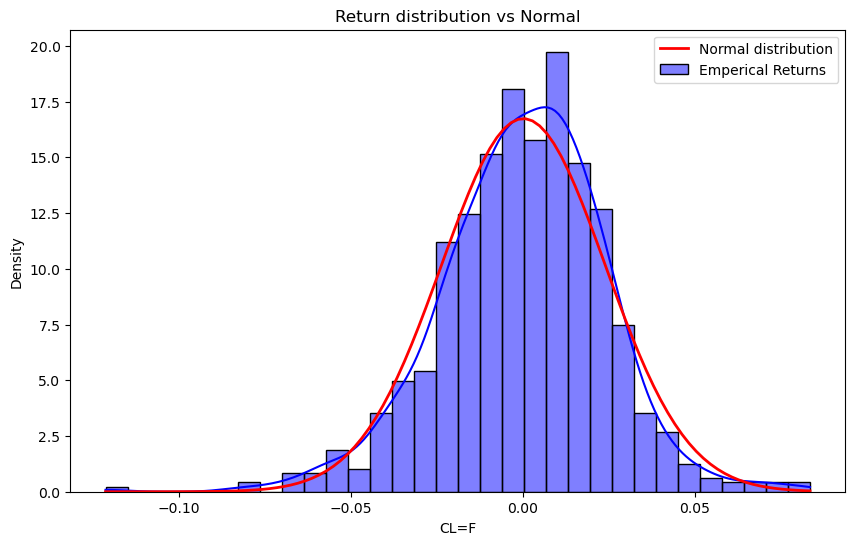

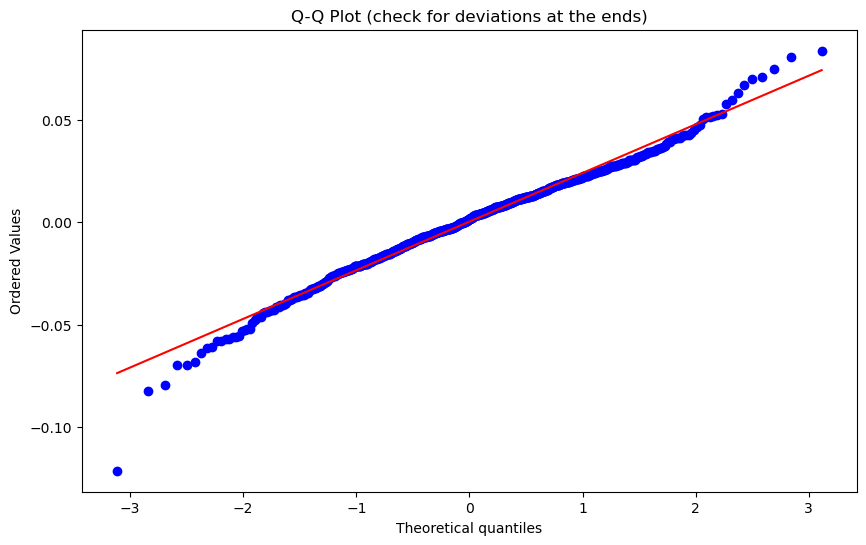

In [225]:
df = get_data()
analyse_tails(df['CL=F'].pct_change())

In [227]:
df

Ticker,BZ=F,CL=F
Date,,
2022-01-03,78.980003,76.080002
2022-01-04,80.000000,76.989998
2022-01-05,80.800003,77.849998
2022-01-06,81.989998,79.459999
2022-01-07,81.750000,78.900002
...,...,...
2024-12-24,73.580002,70.099998
2024-12-26,73.260002,69.620003
2024-12-27,74.169998,70.599998


In [212]:
def implement_robust_strategy(df, x_col, y_col):
    x = df[x_col].values
    y = df[y_col].values

    #initialise state 
    state = np.zeros(2)
    P = np.eye(2)
    Q = np.eye(2) * 1e-5 #process noise 
    R = 0.01

    

    y_pred = []
    betas = []

    for t in range(len(y)):
        #predict 
        P = P + Q

        H = np.array([x[t],1.0]).reshape(1,2)

        prediction = H @ state
        innovation = y[t] - prediction 

        S = H @ P @ H.T + R
        innovation_sigma = np.sqrt(S[0,0])
        z_score = innovation / innovation_sigma

        limit = 3.0
        clipped_innovation = innovation
        if np.abs(z_score) > limit:
            clipped_innovation = np.sign(innovation) * limit * innovation_sigma


        #Update 
        K = P @ H.T @ np.linalg.inv(S)
        state = state + K.flatten() * clipped_innovation 
        P = (np.eye(2) - K @ H) @ P

        y_pred.append(prediction[0])
        betas.append(state[0])

    df['y_hat'] = y_pred
    df['beta'] = betas
    df['spread'] = df[y_col] - df['y_hat']

    df['z_score'] = (df['spread'] - df['spread'].rolling(20).mean()) / df['spread'].rolling(20).std()

    df['signal'] = 0
    df.loc[df['z_score'] > 2 ,'signal'] = -1
    df.loc[df['z_score']< -2, 'signal'] = 1 

    return df

In [214]:
implement_robust_strategy(df, 'CL=F', 'BZ=F')

Ticker,BZ=F,CL=F,y_hat,beta,spread,z_score,signal
Date,,,,,,,
2022-01-03,78.980003,76.080002,0.000000,1.037937,78.980003,NaN,0
2022-01-04,80.000000,76.989998,79.924385,1.038943,0.075615,NaN,0
2022-01-05,80.800003,77.849998,80.884000,1.037828,-0.083997,NaN,0
2022-01-06,81.989998,79.459999,82.481444,1.030731,-0.491446,NaN,0
2022-01-07,81.750000,78.900002,81.472178,1.033629,0.277822,NaN,0
...,...,...,...,...,...,...,...
2024-12-24,73.580002,70.099998,73.456460,0.958284,0.123542,0.470843,0
2024-12-26,73.260002,69.620003,73.101830,0.960186,0.158173,0.537568,0
2024-12-27,74.169998,70.599998,74.177335,0.960093,-0.007337,0.086479,0


In [216]:

df['pct_x'] = df['CL=F'].pct_change()
df['pct_y'] = df['BZ=F'].pct_change()

df['strat_returns'] = df['signal'].shift(1) * (df['pct_y'] - df['beta'].shift(1)* df['pct_x'])
transaction_cost = 0.0002
df['strat_returns'] -= (df['signal'].diff().abs() * transaction_cost)

Final strat val:  1.34


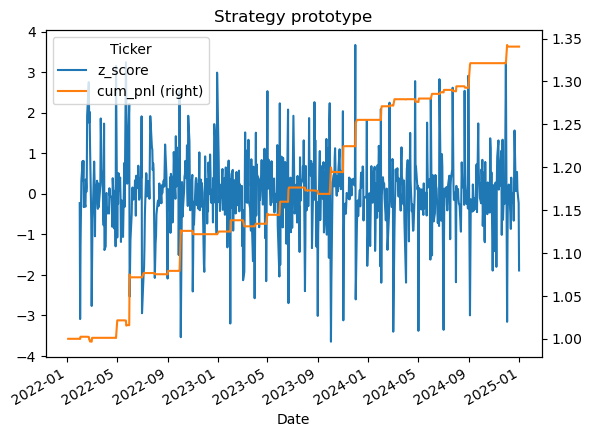

In [218]:
df['cum_pnl'] = (1 + df['strat_returns'].fillna(0)).cumprod()
print(f'Final strat val: {df['cum_pnl'].iloc[-1]: .2f}')
df[['z_score', 'cum_pnl']].plot(secondary_y = 'cum_pnl', title = 'Strategy prototype')
plt.show()

In [220]:
def calc_sharpe(returns, periods = 252):
    adj_returns = returns.dropna()
    sharpe = (adj_returns.mean() / adj_returns.std()) * np.sqrt(periods)
    return sharpe 

calc_sharpe(df['strat_returns'])

1.806435001159996